In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import xarray as xr
from klepto.archives import file_archive
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import numpy.ma as ma
from skimage import measure
from scipy import interpolate
from joblib import Parallel
from scipy.linalg import eig
from joblib import delayed as jb_delayed
from legendkit import legend
from legendkit.layout import vstack, hstack

In [2]:
# utility for calculation of contours. Not required to recreate the figure, but added for completeness. 


def find_nearest(array_x, array_y, value_x, value_y):
    idx = np.sqrt((array_x - value_x)**2 + (array_y - value_y)**2 ).argmin()
    return idx
    
def calc_cont(ssh): # exemplary function on how gulf stream path lines are  calculated.
    
    contours = measure.find_contours(ssh.values, 0) # find 0m sealevel contours.
    
    len_cont = [np.shape(contours[i])[0] for i in range(len(contours))]
    ind = (len_cont - np.max(len_cont)).argmax()
    contour_coors = contours[ind][::-1,:] # choose the longest one
    
    lat_mod = ssh.y
    lon_mod = ssh.x
    
    lat = contour_coors[:,0]/np.shape(ssh)[0]*(lat_mod[-1].values - lat_mod[0].values) + lat_mod[0].values # transform pixel indices to lon/lat coordinates.
    lon = contour_coors[:,1]/np.shape(ssh)[1]*(lon_mod[-1].values - lon_mod[0].values) + lon_mod[0].values
    
    # find starting index of contour.
    lon_aim = -80
    lat_aim = 22.5
    idx_start = find_nearest(lon, lat, lon_aim, lat_aim)
    
    # cut contour to begin from 80°W and 22.5 North.
    
    lat_cont = lat[idx_start:]
    lon_cont = lon[idx_start:]

    return np.array([lon_cont, lat_cont])

In [3]:
# utility for instability analysis.

def Stretching(f0, Hs, g_primes, Nx, Nl):

    ''' builds stretching matrix for the PV operator '''
    
    one_o_H_fac = M(np.concatenate([1/Hs[i]*np.ones(Nx) for i in range(Nl)])) # dividing by layer depths

    # stretching on the upper interface
    upper_stretch_one_o_g = M(np.concatenate([np.zeros(Nx), np.concatenate([1/g_primes[i]*np.ones(Nx) for i in range(Nl-1)])])) # zero stretching in upper layer
    upper_stretch_psi_i = M(np.concatenate([np.zeros(Nx), np.concatenate([np.ones(Nx) for i in range(Nl-1)])])) 
    upper_stretch_psi_i_m1 = np.zeros([Nx*Nl,Nx*Nl])
    upper_stretch_psi_i_m1[Nx:,:-Nx] = M(np.concatenate([np.ones(Nx) for i in range(Nl-1)])) # zero stretching in upper layer

    # stretching on the lower interface
    lower_stretch_one_o_g = M(np.concatenate([np.concatenate([1/g_primes[i]*np.ones(Nx) for i in range(Nl-1)]), np.zeros(Nx)])) # zero stretching in upper layer
    lower_stretch_psi_i = M(np.concatenate([np.concatenate([np.ones(Nx) for i in range(Nl-1)]), np.zeros(Nx)])) 
    lower_stretch_psi_i_p1 = np.zeros([Nx*Nl,Nx*Nl])
    lower_stretch_psi_i_p1[:-Nx,Nx:] = M(np.concatenate([np.ones(Nx) for i in range(Nl-1)])) # zero stretching in upper layer
    
    Stretch = f0**2 * one_o_H_fac @ (upper_stretch_one_o_g @ (upper_stretch_psi_i_m1 - upper_stretch_psi_i) - lower_stretch_one_o_g @ (lower_stretch_psi_i - lower_stretch_psi_i_p1))

    return Stretch

def M(x):
    
    '''builds matrix with entries on the diagonal being equal to the value of the input function x'''
    
    n = len(x)
    M = np.zeros([n, n])
    for i in range(n):
        M[i,i] = x[i]
        
    return M

def Layered(M, Nl):

    ''' builds super matrix that applies matrix M to each layer independently '''
    
    n = np.shape(M)[0]
    L = np.zeros([n*Nl,n*Nl])
    for l in range(Nl):
        L[l*n:(l+1)*n,l*n:(l+1)*n] = M
        
    return L

def D1(n, dx):
    ''' gives back first derivative matrix for vector of n points. free-slip '''
    
    Der = np.zeros([n, n])
    
    # interior
    for i in range(2,n-2):
        Der[i,i-2] = 1
        Der[i,i-1] = -8
        Der[i,i+1] = 8
        Der[i,i+2] = -1
    
    # multiply delta
    Der = Der/(12*dx)
    
    # boundaries
    Der[1, 3] = -15/(210*dx)
    Der[1, 2] = 126/(210*dx)
    Der[1, 1] = 35/(210*dx)
    Der[1, 0] = -210/(210*dx)
    
    Der[0, 2] = -21/(690*dx)
    Der[0, 1] = 220/(690*dx)
    Der[0, 0] = 825/(690*dx)
    
    Der[-2, -1] = 210/(210*dx)
    Der[-2, -2] = -35/(210*dx)
    Der[-2, -3] = -126/(210*dx)
    Der[-2, -4] = 15/(210*dx)    
    
    Der[-1, -1] = -825/(690*dx)
    Der[-1, -2] = -220/(690*dx)
    Der[-1, -3] = 21/(690*dx)
    
    return Der
    
def D2(n, dx):
    ''' gives back second derivative matrix for vector of n points. free-slip '''
    
    Der = np.zeros([n, n])
    
    # interior
    for i in range(2,n-2):
        Der[i,i-2] = -1
        Der[i,i-1] = 16
        Der[i,i] = -30
        Der[i,i+1] = 16
        Der[i,i+2] = -1
    
    # multiply delta
    Der = Der/(12*dx**2)
    
    # boundaries
    Der[1, 3] = -10/(105*dx**2)
    Der[1, 2] = 147/(105*dx**2)
    Der[1, 1] = -280/(105*dx**2)
    Der[1, 0] = 175/(105*dx**2)
    
    Der[0, 2] = -3/(23*dx**2)
    Der[0, 1] = 38/(23*dx**2)
    Der[0, 0] = -99/(23*dx**2)
    
    Der[-2, -1] = 175/(105*dx**2)
    Der[-2, -2] = -280/(105*dx**2)
    Der[-2, -3] = 147/(105*dx**2)
    Der[-2, -4] = -10/(105*dx**2)    
    
    Der[-1, -1] = -99/(23*dx**2)
    Der[-1, -2] = 38/(23*dx**2)
    Der[-1, -3] = -3/(23*dx**2)
    
    return Der

def D4(n, dx):
    ''' gives back fourth derivative matrix for vector of n points. free-slip '''
    
    Der = np.zeros([n, n])
    
    # interior
    for i in range(2,n-2):
        Der[i,i-2] = 1
        Der[i,i-1] = -4
        Der[i,i] = 6
        Der[i,i+1] = -4
        Der[i,i+2] = 1
    
    # multiply delta
    Der = Der/(dx**4)
    
    # boundaries
    Der[1, 3] = 40/(35*dx**4)
    Der[1, 2] = -168/(35*dx**4)
    Der[1, 1] = 280/(35*dx**4)
    Der[1, 0] = -280/(35*dx**4)
    
    Der[0, 2] = 1/(115/192*dx**4)
    Der[0, 1] = -5/(115/192*dx**4)
    Der[0, 0] = 10/(115/192*dx**4)
    
    Der[-2, -1] = -280/(35*dx**4)
    Der[-2, -2] = 280/(35*dx**4)
    Der[-2, -3] = -168/(35*dx**4)
    Der[-2, -4] = 40/(35*dx**4)    
    
    Der[-1, -1] = 10/(115/192*dx**4)
    Der[-1, -2] = -5/(115/192*dx**4)
    Der[-1, -3] = 1/(115/192*dx**4)
    
    return Der

def model(x,z,U_shear, U_off, x_0, decay_scale_horizontal, decay_scale_vertical):
    return np.exp(-(x-x_0)**2/decay_scale_horizontal**2) * (U_shear * np.exp(z/(decay_scale_vertical)) + U_off)

def d2model_dx2(x,z,U_shear, U_off, x_0, decay_scale_horizontal, decay_scale_vertical):
    vorticity =  -2*(decay_scale_horizontal**2 - 2 * (x - x_0)**2)/decay_scale_horizontal**4 * np.exp(-(x-x_0)**2/decay_scale_horizontal**2) * (U_shear*np.exp(z/decay_scale_vertical) + U_off)
    return vorticity

def instability(U_line, dQdx, dQdy, H_m, g_primes, f0, nu, dx, N_prof, Nl, l):
    
    '''  calculates growth rate of the most unstable mode. '''
        
    # code the matrix Mq that gives q from vector psi
    
    I = np.ones(N_prof)
    
    Mq = Layered(D2(N_prof,dx), Nl) - l**2 * Layered(M(I), Nl) + Stretching(f0, H_m, g_primes, N_prof, Nl)
    
    # set up matrices
    
    # LHS: dq/dt = -i*omega*q
    
    LHS = 1j*Mq
    
    # RHS: dQ/dx*dpsi/dy + df/dx*dpsi/dy - df/dy*dpsi/dx - U*dq/dy + nu * nabla^4 psi = dQ/dx*i*l*psi + df/dx*i*l*psi - U*i*l*q + nu * (D4 - 2*D2*l^ + l^4) psi
    
    RHS = M(dQdy) @ Layered(D1(N_prof,dx), Nl) - 1j * l * M(dQdx)  -  1j * l * M(U_line) @ ( l**2 * Layered(M(I), Nl) - Layered(D2(N_prof,dx), Nl) - Stretching(f0, H_m, g_primes, N_prof, Nl) )  + nu * ( - Layered(D4(N_prof,dx), Nl) + 2*Layered(D2(N_prof,dx), Nl)*l**2 - l**4 * Layered(M(I), Nl) )
    
    # calculate eigenvalue problem
    out = eig(RHS, LHS)
    imags = out[0].imag
    
    index = np.where(imags == np.max(imags))[0][0]
    eig_funcs = out[1]
    eig_func = eig_funcs[:,index]
     
    eig_values = out[0]
    eig_value = eig_values[index]
        
    return eig_value, eig_func

In [29]:
drhos = [1,2,4]

# grid over which to perform stability analysis

lmin = 2*np.pi/100e5
lmax = 2*np.pi/100e3
N_l = 100

ls = np.linspace(lmin, lmax, N_l) # np.logspace(np.log10(lmin), np.log10(lmax), N_l)

nu = 100 # viscosity

# superparameters that set the resolution and domain size for the stability analysis (checked for convergence)
dx_rescale = 4
domain_rescale = 1

# width and differentials for profile to be averaged for
profile_widths = 250e3*np.array([1, np.sqrt(2), 2])
dxs = 1e3*np.array([1, np.sqrt(2), 2])
N_prof_fit = int(profile_widths[0]/dxs[0])
N_prof = int(domain_rescale*N_prof_fit/dx_rescale) 

# arrays to hold eigenvalues
Nl = 5 # number of layers
eig_vals = np.zeros([len(drhos), N_l], dtype = complex)
eig_funcs = np.zeros([len(drhos), N_l,N_prof*Nl], dtype = complex)

eig_vals_no_topo = np.zeros([len(drhos), N_l], dtype = complex)
eig_funcs_no_topo = np.zeros([len(drhos), N_l,N_prof*Nl], dtype = complex)

for ind in range(3):

    print("starting drho_fac = " + str(drhos[ind]))
          
    dx = dxs[ind]
    profile_width = profile_widths[ind]
    
    drho_fac = drhos[ind]
    
    # unpack pathwise averaged variables
    
    path_avs_load = np.load("path_averages.npz", allow_pickle = True)["arr_0"][None][0]  # gulf_" + str(drho_fac) + "drho_lin_topo.npz", allow_pickle=True)["arr_0"][None][0]['res']
    
    # Setup quasi-geostrophic stability model. The path averages and fits are calculated in the script in folder Fig_S4
    
    # velocity parameters
    U_shear = path_avs_load["U_shear_means"][ind] #\Delta U
    U_off = path_avs_load["U_off_means"][ind] # U_0
    decay_scale_horizontal = path_avs_load["decay_scale_horizontals"][ind] # \delta_h
    decay_scale_vertical = path_avs_load["decay_scale_verticals"][ind] #\delta_v
    
    # layer depths 
    H_m = path_avs_load["H_ms_means"][ind]
    topo_mean = path_avs_load["topo_means"][ind]
    
    # calculate depth of isopycnal layer interfaces
    z_i = np.zeros(Nl + 1) 
    z_i[1:] = -np.cumsum(H_m)
    z_i = z_i - z_i[-1] + topo_mean
    # calculate depth of isopycnal layers
    z = (z_i[1:] + z_i[:-1])/2
    
    # topography
    dtopo_dx = path_avs_load["dtopodx_means"][ind]
    dtopo_dy = path_avs_load["dtopody_means"][ind]
    
    # background rotation
    f0 = path_avs_load["f0_means"][ind]
    df_dx = path_avs_load["dfdx_means"][ind]
    df_dy = path_avs_load["dfdy_means"][ind]   # R = 6378e3 # radius of the earth
    
    # stratification
    g = 9.81
    rho0 = 1e3 # reference density
    drho = np.array([0.,1.01/rho0, 1.41/rho0,  1.72/rho0,  2.13/rho0])*drho_fac # difference between layers and top layer, top-to-bottom indexed
    g_primes = g*(drho[1:] - drho[:-1]) # reduced density
    
    # Layer Depths
    
    Nl = 5
    
    # create along-across-stream coordinates for instability at lower resolution and wider domain
    
    dx = dxs[ind]*dx_rescale 
    profile_width = domain_rescale * profile_widths[ind]
    
    N_prof = int(profile_width/dx)  # number of points across track
    dx = profile_width/(N_prof - 1) # numerical delta in rotated beta-plane frame
    xs = np.linspace(-profile_width/2, profile_width/2, N_prof)
    
    X,Z = np.meshgrid(xs,z)
    
    # calculate base profiles from fit (negtlect axis-shift)
    
    U_profile = model(X,Z,U_shear, U_off, 0, decay_scale_horizontal, decay_scale_vertical).T
    U_grad2 = d2model_dx2(X,Z,U_shear, U_off, 0, decay_scale_horizontal, decay_scale_vertical).T

    # set U into one-line matrix for instability calculation
    U_line = np.zeros(N_prof*Nl)
    U_grad2_line = np.zeros(N_prof*Nl)
    for nl in range(Nl):
        U_line[nl*N_prof:(nl + 1)*N_prof] = U_profile[:,nl]
        U_grad2_line[nl*N_prof:(nl + 1)*N_prof] = U_grad2[:,nl]
    
    # calculate potential vorticity gradient without topographical gradient
    dQdx = U_grad2_line + Stretching(f0, H_m, g_primes, N_prof, Nl) @ U_line + df_dx
    
    dQdy = np.zeros(np.shape(dQdx))
    dQdy[:] = df_dy
    
    # calculate eigenproblem
    res = Parallel(n_jobs=12,backend='multiprocessing')(jb_delayed(instability)(U_line, dQdx, dQdy, H_m, g_primes, f0, nu, dx, N_prof, Nl, ls[i]) for i in range(N_l))
    
    for k in range(N_l):
        eig_vals_no_topo[ind,k] = res[k][0]
        eig_funcs_no_topo[ind,k,:] = res[k][1]

    # calculate potential vorticity gradient with topography
    dQdx = U_grad2_line + Stretching(f0, H_m, g_primes, N_prof, Nl) @ U_line + df_dx
    dQdx[(Nl-1)*N_prof:(Nl)*N_prof] += f0/H_m[-1]*dtopo_dx # add topography to base layer gradient
    
    dQdy = np.zeros(np.shape(dQdx))
    dQdy[:] = df_dy
    dQdy[(Nl-1)*N_prof:(Nl)*N_prof] += f0/H_m[-1]*dtopo_dy # add topography to base layer gradient
    
    # calculate eigenproblem
    res = Parallel(n_jobs=12,backend='multiprocessing')(jb_delayed(instability)(U_line, dQdx, dQdy, H_m, g_primes, f0, nu, dx, N_prof, Nl, ls[i]) for i in range(N_l))
    
    for k in range(N_l):
        eig_vals[ind,k] = res[k][0]
        eig_funcs[ind,k,:] = res[k][1]

starting drho_fac = 1
starting drho_fac = 2
starting drho_fac = 4


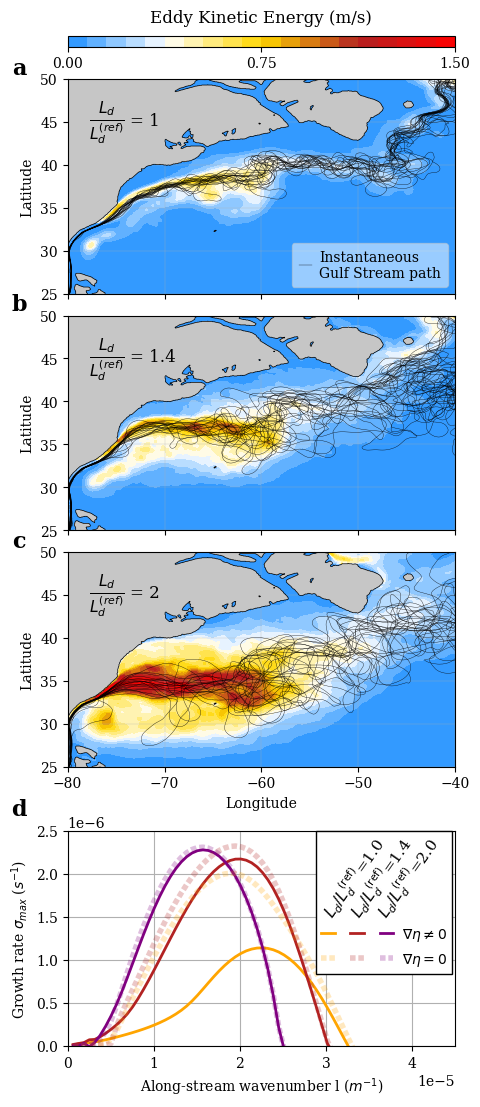

In [30]:
savepath = "data/"

lat_min = 25
lat_max = 50
lon_min = -80
lon_max = -40

drho_facs = [1, 2, 4]

plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(5, 12))
grid = plt.GridSpec(4, 1, hspace=0.1, wspace=0)

cs = ["dodgerblue", "white", "gold", "firebrick", "red"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("cmap_name", cs)

Rd_labels = ["1", "1.4", "2"]
labels = ["a", "b", "c"]
R0 = 39066.430787677964

for i, drho_fac in enumerate(drho_facs):
        
    drho = np.array([ 2.13, 1.72, 1.41, 1.01, 0. ])[::-1]*drho_fac
    
    # open datasets
    
    # topo mask 
    ds_topo = xr.open_dataset(savepath + "topo.nc")
    topo = ds_topo["zb"][0,0,:,:]
    mask = topo < 0
    mx = ma.masked_array(np.zeros(np.shape(topo)), mask=mask)
    zeros = topo*0
        
    # u_std
    ds_std = xr.open_dataset(savepath + "u_std_2048_" + str(drho_fac) + "drho.nc", decode_times=False)
    u_std = ds_std["u.x"]
    lat_mod = u_std.y
    lon_mod = u_std.x
    
    # v_std
    ds_std = xr.open_dataset(savepath + "v_std_2048_" + str(drho_fac) + "drho.nc", decode_times=False)
    v_std = ds_std["u.y"]
    
    eke = u_std[-1,:,:]**2 + v_std[-1,:,:]**2

    axes = fig.add_subplot(grid[i])

    #  kinetic energy

    v = 1.5
    levels = np.linspace(0, v, 21)
    
    axes.pcolormesh(lon_mod, lat_mod, eke, vmin = 0, vmax = v, cmap = cmap)
    cplot = axes.contourf(lon_mod, lat_mod, eke, vmin = 0, vmax = v, levels = levels, cmap = cmap)

    # coastlines
    axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
    axes.contour(lon_mod, lat_mod, topo, levels = [0], colors = "k", linewidths = 0.5)

    if i == 2:
        axes.set_xlabel("Longitude")
    else:
        axes.set_xticklabels([])
    axes.set_ylabel("Latitude")

    axes.text(-0.125, 1.05, labels[i], weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)
    
    axes.set_xticks(np.linspace(-80, -40, 5))
    
    if i == 0:
            
        divider = make_axes_locatable(axes)
        cax = axes.inset_axes((0, 1.15,1, 0.05))
        
        cbar = plt.colorbar(cplot, cax=cax, orientation='horizontal', ticks=[0,0.75, 1.5])
        cax.set_xlabel("Eddy Kinetic Energy (m/s)", size = 12, rotation = 0)
        cax.xaxis.set_label_coords(0.5,3.5)
        
    # add grid
    axes.grid(zorder = 1, linewidth = 0.2)
    
    # set lateral and longitudinal extend
    axes.set_xlim([lon_min, lon_max])
    axes.set_ylim([lat_min, lat_max])
    # axes.set_aspect(1)

    # add text for deformation radius
    axes.text(0.1, 0.8, r'$\frac{L_d}{L_d^{(ref)}}$', horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)
    axes.text(0.16, 0.8075, '= ' + Rd_labels[i], verticalalignment='center', transform=axes.transAxes, size = 12)

    # add spaghettis
    conts_load = np.load(savepath + "conts_" + str(drho_fac) + "drho.npz", allow_pickle=False)
    N_cont = len(conts_load) - 1
    for j in range(0, 200, 10):
        if i == 0 and j == 0:
            cont = conts_load[str(j)]
            plt.plot(cont[0,:], cont[1,:], linewidth = 0.25, alpha = 1, color = "k", label = "Instantaneous\nGulf Stream path")
            plt.legend(loc = "lower right", borderpad = 0.5, frameon = True, fancybox= True, framealpha = 0.5)
        else:
            cont = conts_load[str(j)]
            plt.plot(cont[0,:], cont[1,:], linewidth = 0.25, alpha = 1, color = "k")
    
# add growth rates

axes = fig.add_subplot(grid[3])
axes.set_axis_off()
ax = axes.inset_axes((0, -0.2,1, 1))
        
Ld_ratios = [1, np.sqrt(2), 2]
colors = ["orange", "firebrick", "purple"]

for ind in range(3):
    
    ax.plot(ls, eig_vals[ind,:].imag, label = r'$\frac{L_d}{L_d^{(ref)}}$' + ' = ' + f"{Ld_ratios[ind]:.1f}", color = colors[ind], linewidth = 2)

for ind in range(3):
    # ax.plot(ls, eig_vals_no_topo.imag[ind,:], color = "white", linewidth = 2, alpha = 1)
    ax.plot(ls, eig_vals_no_topo[ind,:].imag, label = r'$L_d/L_d^\text{(ref)}$' + '=' + f"{Ld_ratios[ind]:.1f}", color = colors[ind], linewidth = 4, linestyle = (0,(1,0.5)), alpha = 0.25)

# create gridded legend

bp = 1.6
sp = 38

legend00 = legend(legend_items=[
    ('', '')
], handlelength = -0.1, alignment="center", loc="center", borderpad = -bp)
legend01 = legend(legend_items=[
    ('', '')
], handlelength = -0.1, alignment="center", loc="center", borderpad = -bp)
legend02 = legend(legend_items=[
    ('', '')
], handlelength = 0, alignment="center", loc="center", borderpad = -bp)
legend03 = legend(legend_items=[
    ('', '')
], handlelength = 0, alignment="center", loc="center", borderpad = -bp)

hl = 1
legend10 = legend(legend_items=[
    ('line', '', {'color': 'orange', 'linewidth': '2', 'linestyle':'solid'})
], handlelength = hl, alignment="center", loc="center", borderpad = -bp)
legend11 = legend(legend_items=[
    ('line', '', {'color': 'firebrick', 'linewidth': '2', 'linestyle':'solid'})
], handlelength = hl, alignment="center", loc="center", borderpad = -bp)
legend12 = legend(legend_items=[
    ('line', '', {'color': 'purple', 'linewidth': '2', 'linestyle':'solid'})
], handlelength = hl, alignment="center", loc="center", borderpad = -bp)
legend13 = legend(legend_items=[
    ('', r'$\nabla\eta \neq 0$', )
], handlelength = -1, alignment="center", loc="center", borderpad = -bp)


legend20 = legend(legend_items=[
    ('line', '', {'color': 'orange', 'linewidth': '4', "linestyle" : (0,(1,0.5)), "alpha" : 0.25})
], handlelength = hl, alignment="center", loc="center", borderpad = -bp)
legend21 = legend(legend_items=[
    ('line', '', {'color': 'firebrick', 'linewidth': '4', "linestyle" : (0,(1,0.5)), "alpha" : 0.25})
], handlelength = hl, alignment="center", loc="center", borderpad = -bp)
legend22 = legend(legend_items=[
    ('line', '', {'color': 'purple', 'linewidth': '4', "linestyle" : (0,(1,0.5)), "alpha" : 0.25})
], handlelength = hl, alignment="center", loc="center", borderpad = -bp)
legend23 = legend(legend_items=[
    ('', r'$\nabla\eta = 0$', )
], handlelength = -1, alignment="center", loc="center", borderpad = -bp)

legends1 = hstack([legend00, legend01, legend02, legend03], spacing=sp, frameon=True)
legends2 = hstack([legend10, legend11, legend12, legend13], spacing=sp, frameon=True)
legends3 = hstack([legend20, legend21, legend22, legend23], spacing=sp, frameon=True)
legends = vstack([legends1, legends1, legends1, legends1, legends2,legends3], spacing=sp, frameon=True)

xb = .64
yb = .335
dxb = .1
dyb = .25
ddxb = .07

# divider = make_axes_locatable(ax)
lax = ax.inset_axes((xb,yb,0.05, 0.5))
lax.add_artist(legends)

for ind in range(3):
    lax.text(xb + dxb + ind*ddxb, yb + dyb, r'$L_d/L_d^\text{(ref)}$' + '=' + f"{Ld_ratios[ind]:.1f}", rotation =55, horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 11, zorder = 10)

lax.set_axis_off()

# ax.set_title("Gulf Stream\ndensity profiles", pad = 20)
ax.set_xlim([0,4.5e-5])
ax.set_ylim([0, 2.5e-6])
ax.grid()
ax.set_xlabel("Along-stream wavenumber l " + r"($m^{-1}$)")
ax.set_ylabel("Growth rate " + r"$\sigma_{max}$ ($s^{-1}$)")
# ax.legend()
ax.text(-0.125, 0.9, "d", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)

plt.savefig('gulf_stream_spaghetti_EKE_growth_rates.png', dpi = 200, bbox_inches='tight', format = 'png')